In [ ]:
# Three kinds of errors most happened in PyTorch
# 1. Shape Error. Dimension Mismatches.
# 2. Data Type Error. Incorrect Tensor Types.
# 3. Device Error. CPU/GPU Issues.

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# Cheak PyTorch Version
torch.__version__

'2.6.0+cu124'

In [ ]:
# Creat parameters
weight = 0.7
bias = 0.3

# Creat data
strat = 0
end = 1
step = 0.02
X = torch.arange(strat, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# Creat train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [ ]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
  """
  Plots training data, test data and compare predictions
  """
  plt.figure(figsize= (10,7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c='b', s=4, label='Training Data')

  # Plot test data in green
  plt.scatter(test_data, test_labels, c='g', s=4, label='Test Data')

  if predictions is not None:
    # Plot the predictions in red(predictions were made on the test data)
    plt.scatter(test_data, predictions, c='r',s=4, label='Perdictions')

  # Show the lengend
  plt.legend(prop = {'size':14})

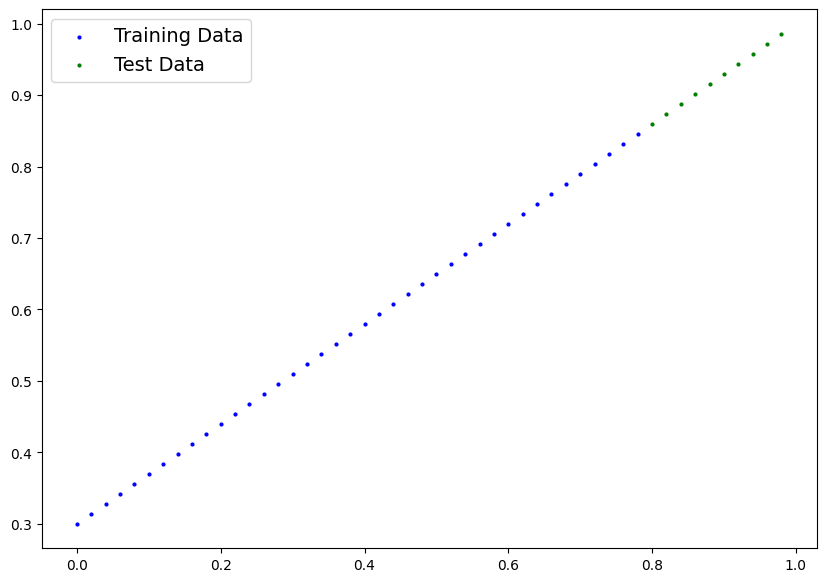

In [ ]:
plot_predictions()

In [ ]:
# Creat a Liner Regreession Model Class
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, dtype=torch.float,
                                requires_grad=True))
    self.bias = nn.Parameter(torch.randn(1,dtype=torch.float,
                              requires_grad=True))
  # Forward define the computation in the model
  def forward(self, x: torch.Tensor):
    return self.weights * x + self.bias

In [ ]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Creat an instrance of the model
model_0 = LinearRegressionModel()

# Chec the nn.Parameter(s) within the nn.Model subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# Make predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)

In [ ]:
# Check the predictions
print(f'Number of test samples: {len(X_test)}')
print(f'Number of preds samples: {len(y_preds)}')
print(f'First 10 preds: {y_preds[:10]}')

Number of test samples: 10
Number of preds samples: 10
First 10 preds: tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


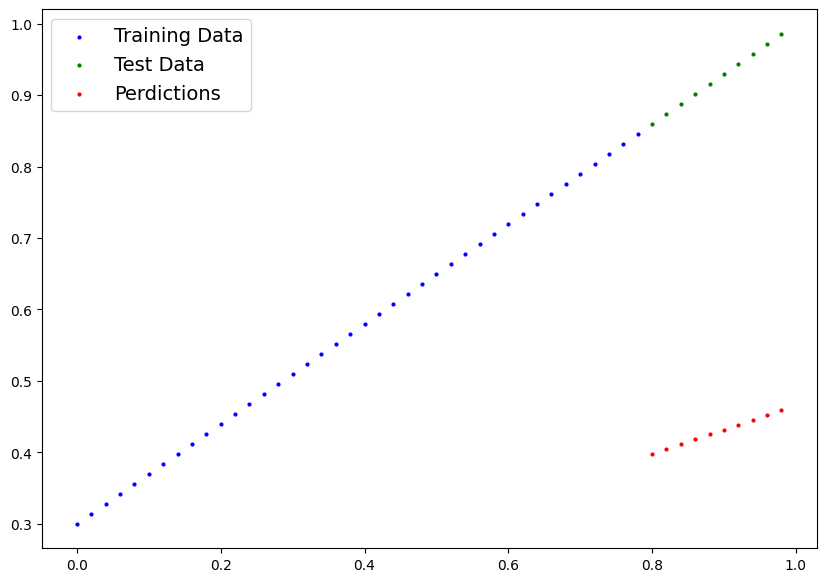

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

In [ ]:
# Creat the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Creat the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [ ]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Creat empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
  # Training
  # Put the model in training model
  model_0.train()

  # 1. Forward pass on train data using the froward() method inside
  y_preds = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_preds, y_train)

  # 3. Zero grad of the optimizer
  optimizer.zero_grad()

  # 4. Loss backwards
  loss.backward()

  # 5. Progress the optimizer
  optimizer.step()

  # Testing
  # Put the model in evaluation model
  model_0.eval()

  with torch.inference_mode():
    # 1. Forward pass on test data
    test_preds = model_0(X_test)

    # 2. Caculate loss on test data
    test_loss = loss_fn(test_preds, y_test.type(torch.float))

    # print out what's happening
    if epoch % 10 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())
      print(f'Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss}')

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819


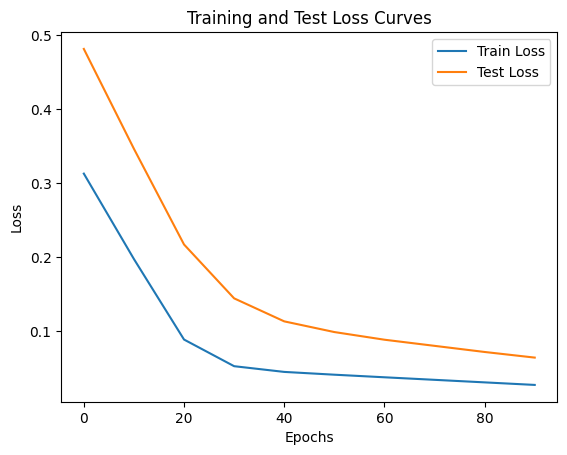

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label = 'Train Loss')
plt.plot(epoch_count, test_loss_values, label = 'Test Loss')
plt.title('Training and Test Loss Curves')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()

In [ ]:
# Find our model's learned parameters
print('The model learned the following values for weights and bias:')
print(model_0.state_dict())
print('\nAnd the original values for weights and bias are:')
print(f'weights:{weight}, bias:{bias}')

The model learned the following values for weights and bias:
OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

And the original values for weights and bias are:
weights:0.7, bias:0.3


In [ ]:
# 1. Set the model in evaluation model
model_0.eval()

# 2. Setup the inference model context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # on the CPU by default
  # model_0.to(device)
  # X_test = x_test.to(device)
  y_preds = model_0(X_test)
y_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

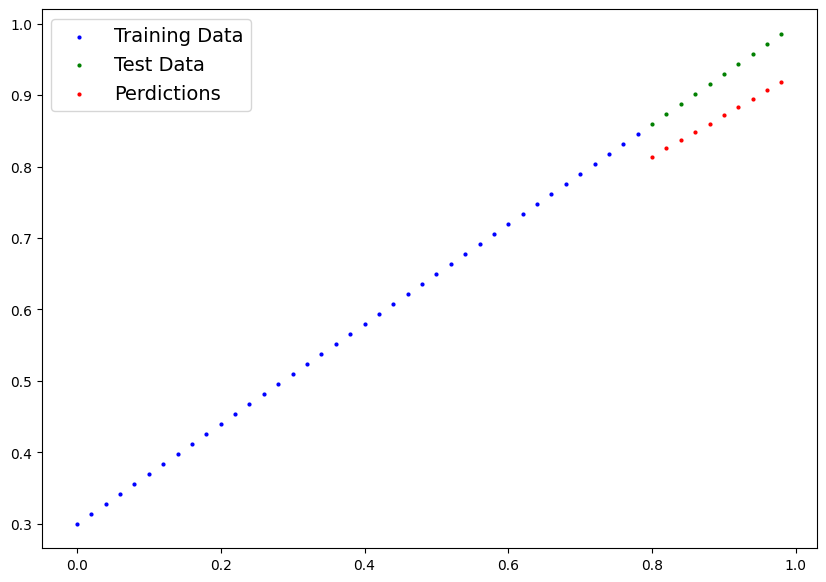

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create models save path
MODEL_NAME = '01_pytorch_workflow_model_0.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the models state dict
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)
print(f'Model saved to: {MODEL_SAVE_PATH}')

Model saved to: models/01_pytorch_workflow_model_0.pth


In [ ]:
# Check the saved file path
!ls -l models/01_pytorch_workflow_model_0.pth

-rw-r--r-- 1 root root 1680 Apr  7 15:40 models/01_pytorch_workflow_model_0.pth


In [ ]:
# Instantiate a fresh instance of LinearRegressionModel
loaded_model_0 = LinearRegressionModel()

# Load model state dict
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Put model to target device
#loaded_model_1.to(device)

print(f'Loaded model:\n{loaded_model_0}')
#print(f'Model on device:\n{next(loaded_model_0.parameters()).device}')

Loaded model:
LinearRegressionModel()


In [ ]:
# 1. Put the loaded model into evaluation mode
loaded_model_0.eval()

# 2. Use the inference mode context manager to make predictions
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test) # perform a forward pass on the test data with the loaded model

In [ ]:
# Compare previous model predictions with loaded model predictions (these should be the same)
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])